In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('toxic-comments.csv')

In [3]:
df.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [4]:
df.shape

(159571, 8)

In [5]:
df.columns

Index(['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat',
       'insult', 'identity_hate'],
      dtype='object')

In [6]:
toxicities=['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

In [7]:
comments=df.sum(numeric_only=True)
comments

toxic            15294
severe_toxic      1595
obscene           8449
threat             478
insult            7877
identity_hate     1405
dtype: int64

([<matplotlib.patches.Wedge at 0x13affdb0980>,
 [Text(0.22052288704922637, 1.077668620814151, 'toxic'),
  Text(-1.0627685748125797, 0.28376567162156585, 'severe_toxic'),
  Text(-0.8835448513040229, -0.655246896775675, 'obscene'),
  Text(-0.1465640005926253, -1.0901921820166778, 'threat'),
  Text(0.6339462415225215, -0.8989505897764732, 'insult'),
  Text(1.0913127724060203, -0.13797257982470842, 'identity_hate')],
 [Text(0.12028521111775983, 0.5878192477168096, '43.58%'),
  Text(-0.5796919498977706, 0.154781275429945, '4.54%'),
  Text(-0.48193355525673975, -0.35740739824127726, '24.07%'),
  Text(-0.07994400032325015, -0.594650281100006, '1.36%'),
  Text(0.34578885901228446, -0.4903366853326217, '22.44%'),
  Text(0.5952615122214656, -0.07525777081347731, '4.00%')])

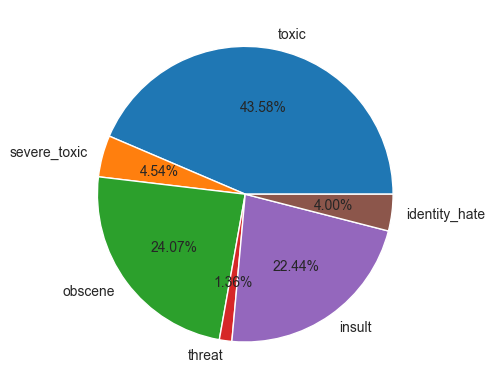

In [8]:
plt.pie(comments.values,labels=comments.index,autopct='%2.2f%%')

In [9]:
total=df.sum(numeric_only=True,axis=1)
total

0         0
1         0
2         0
3         0
4         0
         ..
159566    0
159567    0
159568    0
159569    0
159570    0
Length: 159571, dtype: int64

In [10]:
neutral=sum(total==0)
toxic=sum(total!=0)

In [11]:
neutral,toxic

(143346, 16225)

In [12]:
newdf=pd.DataFrame({
    'neutral':[sum(total==0)],
    'toxic':[sum(total!=0)],
})
newdf.shape

(1, 2)

In [13]:
newdf

,neutral,toxic
0,143346,16225


In [14]:
newsr=pd.Series([neutral,toxic],index=['neutral','toxic'])

In [15]:
newsr

neutral    143346
toxic       16225
dtype: int64

<BarContainer object of 2 artists>

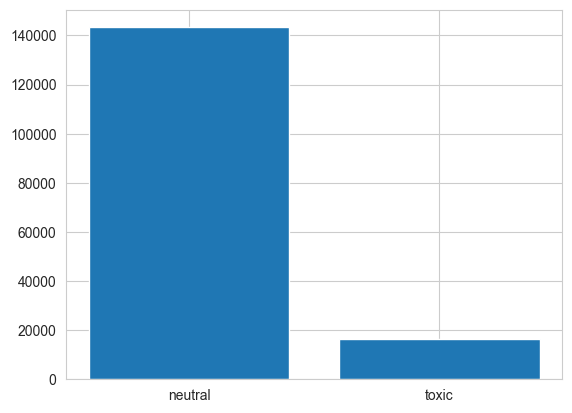

In [16]:
plt.bar(newsr.index,newsr.values)

<Axes: xlabel='None', ylabel='count'>

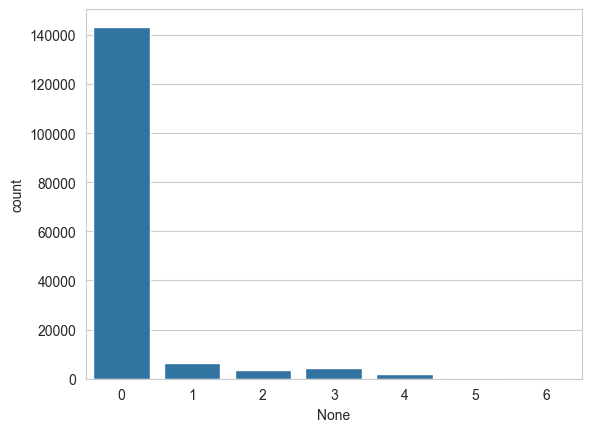

In [17]:
sns.countplot(x=total)

<Axes: xlabel='None', ylabel='count'>

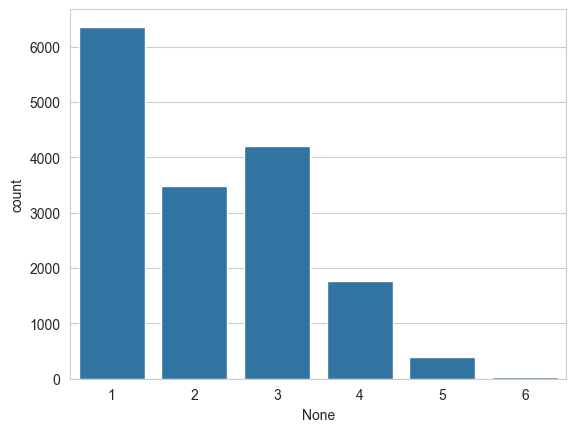

In [18]:
only_toxic=total[total!=0]
sns.countplot(x=only_toxic)

In [19]:
pd.Series(only_toxic).value_counts()

1    6360
3    4209
2    3480
4    1760
5     385
6      31
Name: count, dtype: int64

In [20]:
import re

In [21]:
def clean_text(text):
    text=text.lower()
    text=re.sub('[^a-z0-9]',' ',text)
    return text

In [22]:
text='Hello! How are you?'
clean_text(text)

'hello  how are you '

In [23]:
comment_text=df['comment_text'].apply(clean_text)

In [24]:
comment_text

0         explanation why the edits made under my userna...
1         d aww  he matches this background colour i m s...
2         hey man  i m really not trying to edit war  it...
3           more i can t make any real suggestions on im...
4         you  sir  are my hero  any chance you remember...
                                ...                        
159566          and for the second time of asking  when ...
159567    you should be ashamed of yourself   that is a ...
159568    spitzer   umm  theres no actual article for pr...
159569    and it looks like it was actually you who put ...
159570      and     i really don t think you understand ...
Name: comment_text, Length: 159571, dtype: object

In [30]:
import numpy as np

In [33]:
labels=df[toxicities].values

In [34]:
labels

array([[0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       ...,
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0]], shape=(159571, 6))

In [35]:
#Prepare the input data
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential
from keras.layers import Embedding,LSTM,Dense,GRU
from sklearn.model_selection import train_test_split

In [37]:
tokenizer=Tokenizer(num_words=5000)
tokenizer.fit_on_texts(comment_text)
sequences=tokenizer.texts_to_sequences(comment_text)
padded=pad_sequences(sequences, maxlen=200)

In [38]:
padded.shape

(159571, 200)

In [39]:
padded[0]

array([   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,   

In [40]:
# Cross Validation
x_train,x_test,y_train,y_test=train_test_split(padded,labels,test_size=0.2,random_state=0)

In [41]:
x_train.shape,y_train.shape

((127656, 200), (127656, 6))

In [42]:
x_test.shape,y_test.shape

((31915, 200), (31915, 6))

In [43]:
#Build the model
model=Sequential()
model.add(Embedding(5000,100,input_length=200))
model.add(GRU(64))
model.add(Dense(6,activation='sigmoid'))

C:\Users\dai\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [46]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [47]:
#Train the model
model.fit(x_train,y_train,epochs=3,validation_data=(x_test,y_test))

Epoch 1/3
3990/3990 ━━━━━━━━━━━━━━━━━━━━ 431s 107ms/step - accuracy: 0.9873 - loss: 0.0624 - val_accuracy: 0.9936 - val_loss: 0.0511
Epoch 2/3
3990/3990 ━━━━━━━━━━━━━━━━━━━━ 419s 105ms/step - accuracy: 0.9887 - loss: 0.0462 - val_accuracy: 0.9926 - val_loss: 0.0478
Epoch 3/3
3990/3990 ━━━━━━━━━━━━━━━━━━━━ 411s 103ms/step - accuracy: 0.9825 - loss: 0.0416 - val_accuracy: 0.9811 - val_loss: 0.0496


In [48]:
absolute_cinema=sum(total==6)

In [49]:
absolute_cinema

31

In [53]:
df[sum(df[toxicities])==6]

TypeError: sum() got an unexpected keyword argument 'axis'

In [51]:
df[toxicities]

,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0,0,0,0,0,0
1,0,0,0,0,0,0
2,0,0,0,0,0,0
3,0,0,0,0,0,0
4,0,0,0,0,0,0
...,...,...,...,...,...,...
159566,0,0,0,0,0,0
159567,0,0,0,0,0,0
159568,0,0,0,0,0,0
159569,0,0,0,0,0,0
